<a href="https://www.kaggle.com/code/hrishikeshthakur7/particletrackusinggnn?scriptVersionId=306165004" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

## Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors
import torch
import torch.nn as nn

In [2]:
pip install torch_geometric > /dev/null

Note: you may need to restart the kernel to use updated packages.


In [3]:
from torch_geometric.data import Data

from torch_geometric.nn import GCNConv

## Load and analyse data

In [4]:
hits = pd.read_csv("/kaggle/input/datasets/hrishikeshthakur7/trackml/train_100_events/event000001000-hits.csv")
truth = pd.read_csv("/kaggle/input/datasets/hrishikeshthakur7/trackml/train_100_events/event000001000-truth.csv")

df = hits.merge(truth, on="hit_id")

In [5]:
df.head()

,hit_id,x,y,z,volume_id,layer_id,module_id,particle_id,tx,ty,tz,tpx,tpy,tpz,weight
0,1,-64.4099,-7.163700,-1502.5,7,2,1,0,-64.4116,-7.164120,-1502.5,250710.000000,-149908.000000,-956385.00000,0.000000
1,2,-55.3361,0.635342,-1502.5,7,2,1,22525763437723648,-55.3385,0.630805,-1502.5,-0.570605,0.028390,-15.49220,0.000010
2,3,-83.8305,-1.143010,-1502.5,7,2,1,0,-83.8280,-1.145580,-1502.5,626295.000000,-169767.000000,-760877.00000,0.000000
3,4,-96.1091,-8.241030,-1502.5,7,2,1,297237712845406208,-96.1229,-8.230360,-1502.5,-0.225235,-0.050968,-3.70232,0.000008
4,5,-62.6736,-9.371200,-1502.5,7,2,1,418835796137607168,-62.6594,-9.375040,-1502.5,-0.281806,-0.023487,-6.57318,0.000009


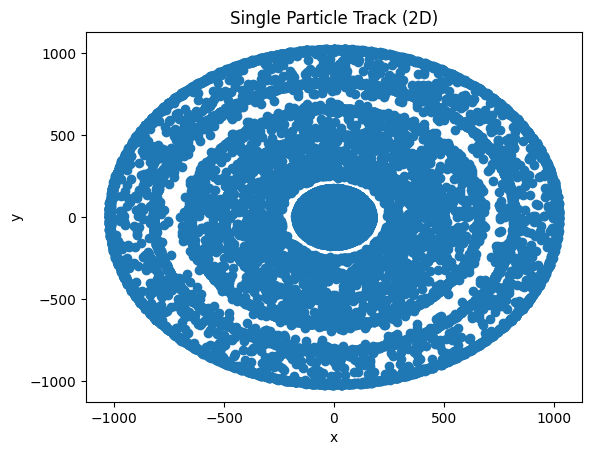

In [6]:
particle = df[df['particle_id'] == df['particle_id'].unique()[0]]

plt.scatter(particle['x'], particle['y'])
plt.title("Single Particle Track (2D)")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

## Build Graph

In [7]:
coords = df[['x', 'y', 'z']].values

nbrs = NearestNeighbors(n_neighbors=10).fit(coords)
distances, indices = nbrs.kneighbors(coords)

## Create Edges

In [8]:
edge_index = []

for i, neighbors in enumerate(indices):
    for j in neighbors:
        edge_index.append([i, j])

edge_index = np.array(edge_index).T

## Create Labels

In [9]:
labels = []

for i, j in edge_index.T:
    if df.iloc[i]['particle_id'] == df.iloc[j]['particle_id']:
        labels.append(1)  # same track
    else:
        labels.append(0)

labels = np.array(labels)

## Convert to pytorch geometric data

In [10]:
x = torch.tensor(coords, dtype=torch.float)

edge_index = torch.tensor(edge_index, dtype=torch.long) if not isinstance(edge_index, torch.Tensor) else edge_index.clone().detach().long()

y = torch.tensor(labels, dtype=torch.float)

data = Data(x=x, edge_index=edge_index, y=y)

## GNN Model

In [11]:
class GNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = GCNConv(3, 64)
        self.conv2 = GCNConv(64, 32)

        # Edge classifier
        self.edge_mlp = nn.Sequential(
            nn.Linear(32 * 2, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )

    def forward(self, data):
        x, edge_index = data.x, data.edge_index

        # Step 1: Node embeddings
        x = self.conv1(x, edge_index)
        x = torch.relu(x)

        x = self.conv2(x, edge_index)
        x = torch.relu(x)

        # Step 2: Get edge node pairs
        row, col = edge_index

        # Step 3: Concatenate node embeddings
        edge_features = torch.cat([x[row], x[col]], dim=1)

        # Step 4: Predict per edge
        out = self.edge_mlp(edge_features)

        return out.squeeze()


## Train model

In [12]:
model = GNN()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
loss_fn = nn.BCEWithLogitsLoss()

for epoch in range(50):
    model.train()
    optimizer.zero_grad()

    out = model(data)  # now matches edge labels
    loss = loss_fn(out, data.y)

    loss.backward()
    optimizer.step()

    print(f"Epoch {epoch}, Loss: {loss.item()}")

Epoch 0, Loss: 5.707310676574707
Epoch 1, Loss: 3.850557327270508
Epoch 2, Loss: 2.4831125736236572
Epoch 3, Loss: 2.622401475906372
Epoch 4, Loss: 2.692641258239746
Epoch 5, Loss: 1.554219126701355
Epoch 6, Loss: 1.456021785736084
Epoch 7, Loss: 1.6304134130477905
Epoch 8, Loss: 1.7809044122695923
Epoch 9, Loss: 1.7940219640731812
Epoch 10, Loss: 1.6445386409759521
Epoch 11, Loss: 1.3610438108444214
Epoch 12, Loss: 1.0384174585342407
Epoch 13, Loss: 1.1528526544570923
Epoch 14, Loss: 1.1468604803085327
Epoch 15, Loss: 0.9615306258201599
Epoch 16, Loss: 0.9796916246414185
Epoch 17, Loss: 0.9531425833702087
Epoch 18, Loss: 0.9625405073165894
Epoch 19, Loss: 0.9542778730392456
Epoch 20, Loss: 0.8906412720680237
Epoch 21, Loss: 0.7998279333114624
Epoch 22, Loss: 0.7833764553070068
Epoch 23, Loss: 0.8831019997596741
Epoch 24, Loss: 0.80958491563797
Epoch 25, Loss: 0.7001643180847168
Epoch 26, Loss: 0.714835524559021
Epoch 27, Loss: 0.7482301592826843
Epoch 28, Loss: 0.7568474411964417
Epoc

## Evaluation


### Prediction

In [13]:
model.eval()

with torch.no_grad():
    logits = model(data)
    probs = torch.sigmoid(logits)   # convert to probabilities
    preds = (probs > 0.5).float()   # threshold

### Accuracy

In [14]:
accuracy = (preds == data.y).float().mean()
print("Edge Accuracy:", accuracy.item())

Edge Accuracy: 0.7866594195365906


### Precision/Recall/F1 Score

In [15]:
from sklearn.metrics import precision_score, recall_score, f1_score

y_true = data.y.cpu().numpy()
y_pred = preds.cpu().numpy()

precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Precision: 0.17390934023814797
Recall: 0.04646220082192903
F1 Score: 0.0733326150199332


### ROC AUC Score

In [16]:
from sklearn.metrics import roc_auc_score

y_probs = probs.cpu().numpy()
roc_auc = roc_auc_score(y_true, y_probs)

print("ROC-AUC:", roc_auc)

ROC-AUC: 0.49983485691121265


# Visualisation

### True Track Visualisation

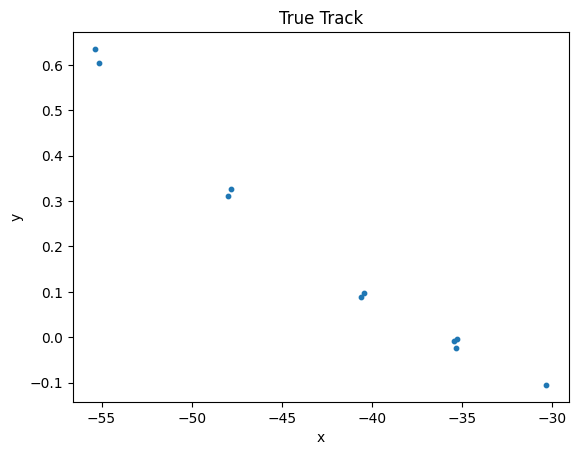

In [17]:
import matplotlib.pyplot as plt

# pick a real particle (ignore noise = particle_id 0)
valid_particles = df[df['particle_id'] != 0]['particle_id'].unique()
pid = valid_particles[0]

track = df[df['particle_id'] == pid]

plt.scatter(track['x'], track['y'], s=10)
plt.title("True Track")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

### Predicted Track visualisation

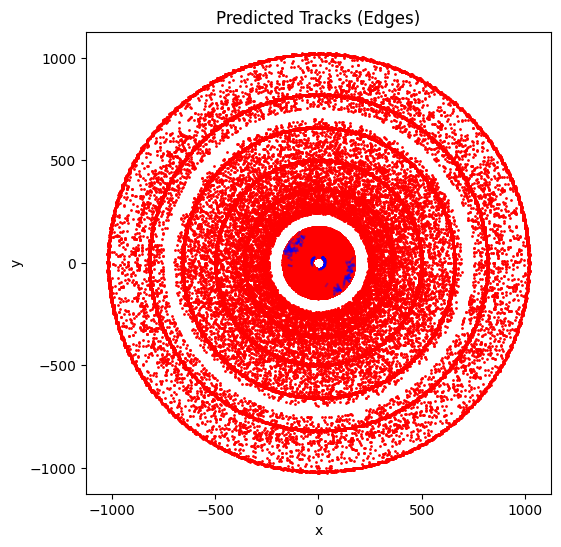

In [18]:
coords = data.x.cpu().numpy()
edge_index_np = data.edge_index.cpu().numpy()
pred_edges = edge_index_np[:, preds.cpu().numpy() == 1]

plt.figure(figsize=(6,6))

for i, j in pred_edges.T[:500]:  # limit for clarity
    x_vals = [coords[i][0], coords[j][0]]
    y_vals = [coords[i][1], coords[j][1]]
    plt.plot(x_vals, y_vals, 'b-', alpha=0.3)

plt.scatter(coords[:,0], coords[:,1], s=1, color='red')
plt.title("Predicted Tracks (Edges)")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

## True Track vs Predicted Track

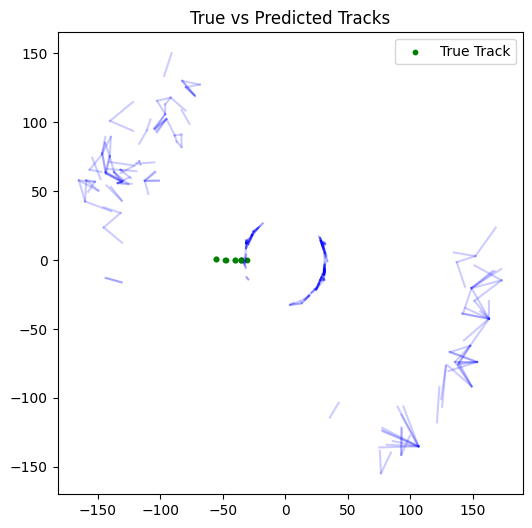

In [19]:
plt.figure(figsize=(6,6))

# true track
plt.scatter(track['x'], track['y'], color='green', label='True Track', s=10)

# predicted edges
for i, j in pred_edges.T[:300]:
    plt.plot([coords[i][0], coords[j][0]],
             [coords[i][1], coords[j][1]],
             'blue', alpha=0.2)

plt.legend()
plt.title("True vs Predicted Tracks")
plt.show()